AI-Driven Employee Attrition Prediction project

##1. Business Understanding

Employee attrition is one of the major challenges faced by organizations because employees leaving the company can affect productivity, project completion, and overall business performance. In this project, the company has observed an increase in employee resignations over the last two years. The HR department currently depends on manual analysis and assumptions to identify employees who may leave the organization, which is often time-consuming and inaccurate. Therefore, the company wants to use Artificial Intelligence and Machine Learning techniques to predict employee attrition and identify employees who are at risk of leaving the organization at an early stage.

Employee retention is very important for an organization because experienced employees contribute significantly to productivity, teamwork, and organizational growth. Retaining skilled employees helps companies reduce recruitment and training costs, maintain project continuity, and improve employee morale. When employees stay longer in the organization, they gain experience and help improve the quality and efficiency of work.

High employee attrition can create several negative impacts on a business. Frequent resignations increase recruitment and training expenses because the company must continuously hire and train new employees. Attrition can also lead to loss of experienced employees, reduced productivity, project delays, and lower employee morale. In addition, excessive employee turnover may affect customer satisfaction and overall organizational performance. Therefore, predicting and reducing employee attrition is important for maintaining business stability and long-term growth.

## 2 .Data understanding

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.metrics import f1_score,confusion_matrix,classification_report

Load Dataset

In [34]:
df=pd.read_csv('/content/drive/MyDrive/csv files/employee_attrition_dataset.csv')

In [35]:
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No




dataset exploration

In [36]:
df.shape

(1000, 26)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    1000 non-null   int64 
 1   Age                            1000 non-null   int64 
 2   Gender                         1000 non-null   object
 3   Marital_Status                 1000 non-null   object
 4   Department                     1000 non-null   object
 5   Job_Role                       1000 non-null   object
 6   Job_Level                      1000 non-null   int64 
 7   Monthly_Income                 1000 non-null   int64 
 8   Hourly_Rate                    1000 non-null   int64 
 9   Years_at_Company               1000 non-null   int64 
 10  Years_in_Current_Role          1000 non-null   int64 
 11  Years_Since_Last_Promotion     1000 non-null   int64 
 12  Work_Life_Balance              1000 non-null   int64 
 13  Job_

info method used to understand data types,Analyze the data ,categorical or numerical features.

Missing Value Analysis

In [38]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0


All columns  values show 0,so the dataset has no missing values

Duplicate checking

In [39]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
995,False
996,False
997,False
998,False


In [40]:
df.duplicated().sum()

np.int64(0)

There are zero duplicate rows in dataframe.Every row is unique.

Statistical summary

In [41]:
df.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,39.991000,3.055000,11499.899000,57.837000,14.922000,7.539000,4.40800,2.495000,3.151000,2.52700,50.043000,4.877000,44.553000,9.524000,2.494000,2.519000,2.503000,24.507000,2.484000
std,288.819436,11.780055,1.399977,4920.529231,24.702037,8.350548,4.001061,2.99508,1.105077,1.426967,1.13073,28.204657,2.546833,8.704192,5.973534,1.110494,1.106736,1.099636,14.138099,1.111296
min,1.000000,20.000000,1.000000,3001.000000,15.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.00000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,250.750000,30.000000,2.000000,7395.750000,36.000000,8.000000,4.000000,2.00000,2.000000,2.000000,2.00000,26.000000,3.000000,37.000000,4.000000,2.000000,2.000000,2.000000,12.000000,1.000000
50%,500.500000,41.000000,3.000000,11256.000000,58.000000,15.000000,8.000000,4.00000,3.000000,3.000000,3.00000,50.000000,5.000000,45.000000,9.000000,2.000000,3.000000,3.000000,24.000000,2.000000
75%,750.250000,50.250000,4.000000,15855.000000,80.000000,22.000000,11.000000,7.00000,3.000000,4.000000,4.00000,75.250000,7.000000,52.000000,15.000000,4.000000,4.000000,3.000000,37.000000,3.000000
max,1000.000000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.00000,4.000000,5.000000,4.00000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


3.Exploratory Data Analysis(EDA)

Analyze and visualiize:
• Attrition distribution




  


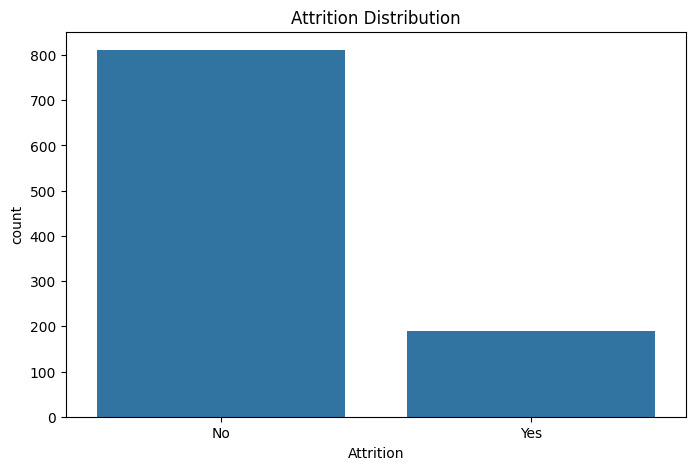

In [42]:
plt.figure(figsize=(8,5))
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()

this graph is an attrition distribution bar chart.'No' is ¬800 employees.'yes' is ¬200.this dataset is highly imbalanced.80% of employees have stayed with the company,while 20% have left.so HR should focus on identifying high risk employees early.




• Attrition by department

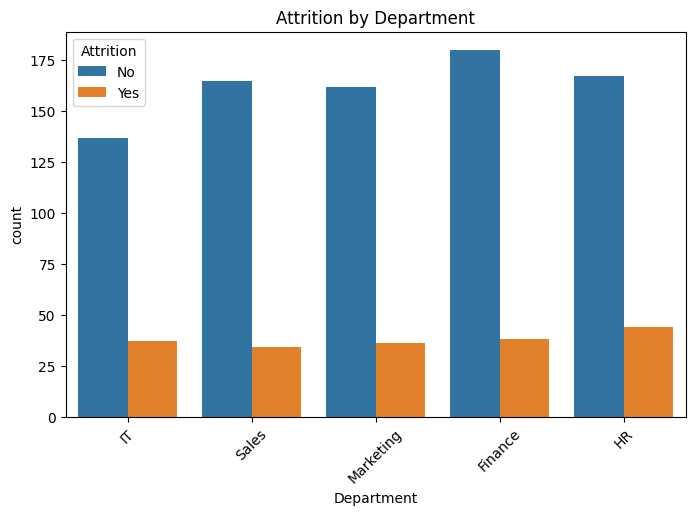

In [43]:
plt.figure(figsize=(8,5))
sns.countplot(x='Department',hue='Attrition',data=df)
plt.xticks(rotation=45)
plt.title('Attrition by Department')
plt.show()

Business insights

Across all departments,the majority of employees have stayed with the company.However,attrition exists in every department

• Attrition by overtime

In [44]:
print(df.columns)

Index(['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department',
       'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime',
       'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Attrition'],
      dtype='object')


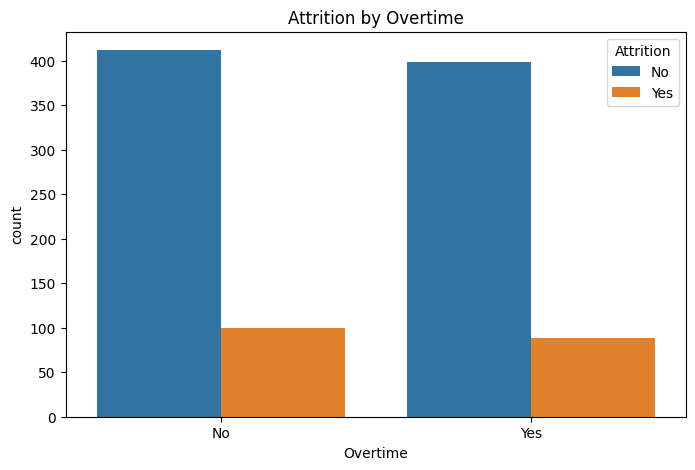

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(x='Overtime', hue='Attrition', data=df)
plt.title('Attrition by Overtime')
plt.show()

from the bar heights it looks almost 1:1.So in this company dataset ,burnout from extra hours isn't pushing people out.

• Attrition by salary

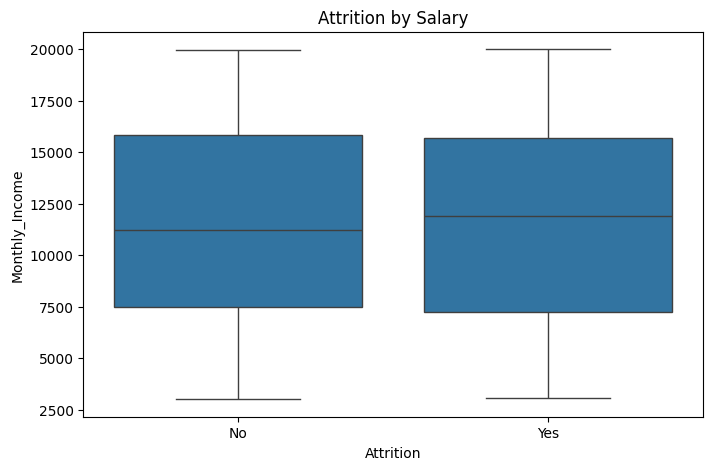

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='Monthly_Income', data=df)
plt.title('Attrition by Salary')
plt.show()

Monthly income shows minimal difference between employees who stayed vs left.The median salary for both groups approximately same.This indicates that salary alone is not a primary driver of attrition in this dataset.Both low and high earners are leaving at similar rates.


• Attrition by job satisfaction

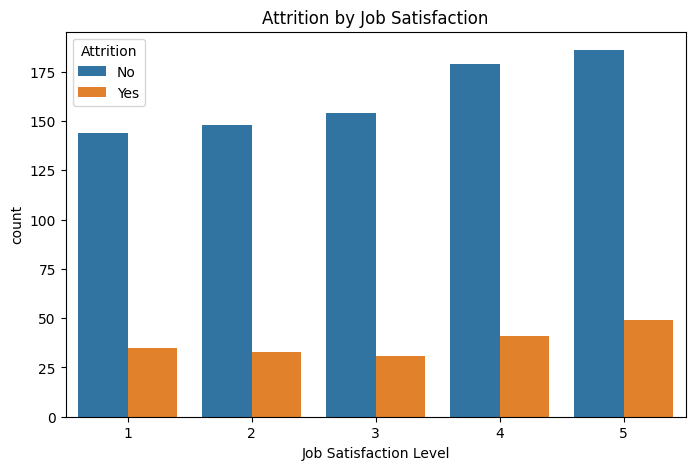

In [47]:
plt.figure(figsize=(8,5))
sns.countplot(x='Job_Satisfaction', hue='Attrition', data=df)
plt.title('Attrition by Job Satisfaction')
plt.xlabel('Job Satisfaction Level')
plt.show()

Attrition rate is highest at satisfaction level 5 and lowest at level 3.employees with very high jobsatisfaction are leaving slightly more than dissatisfied employees.



• Correlation between features



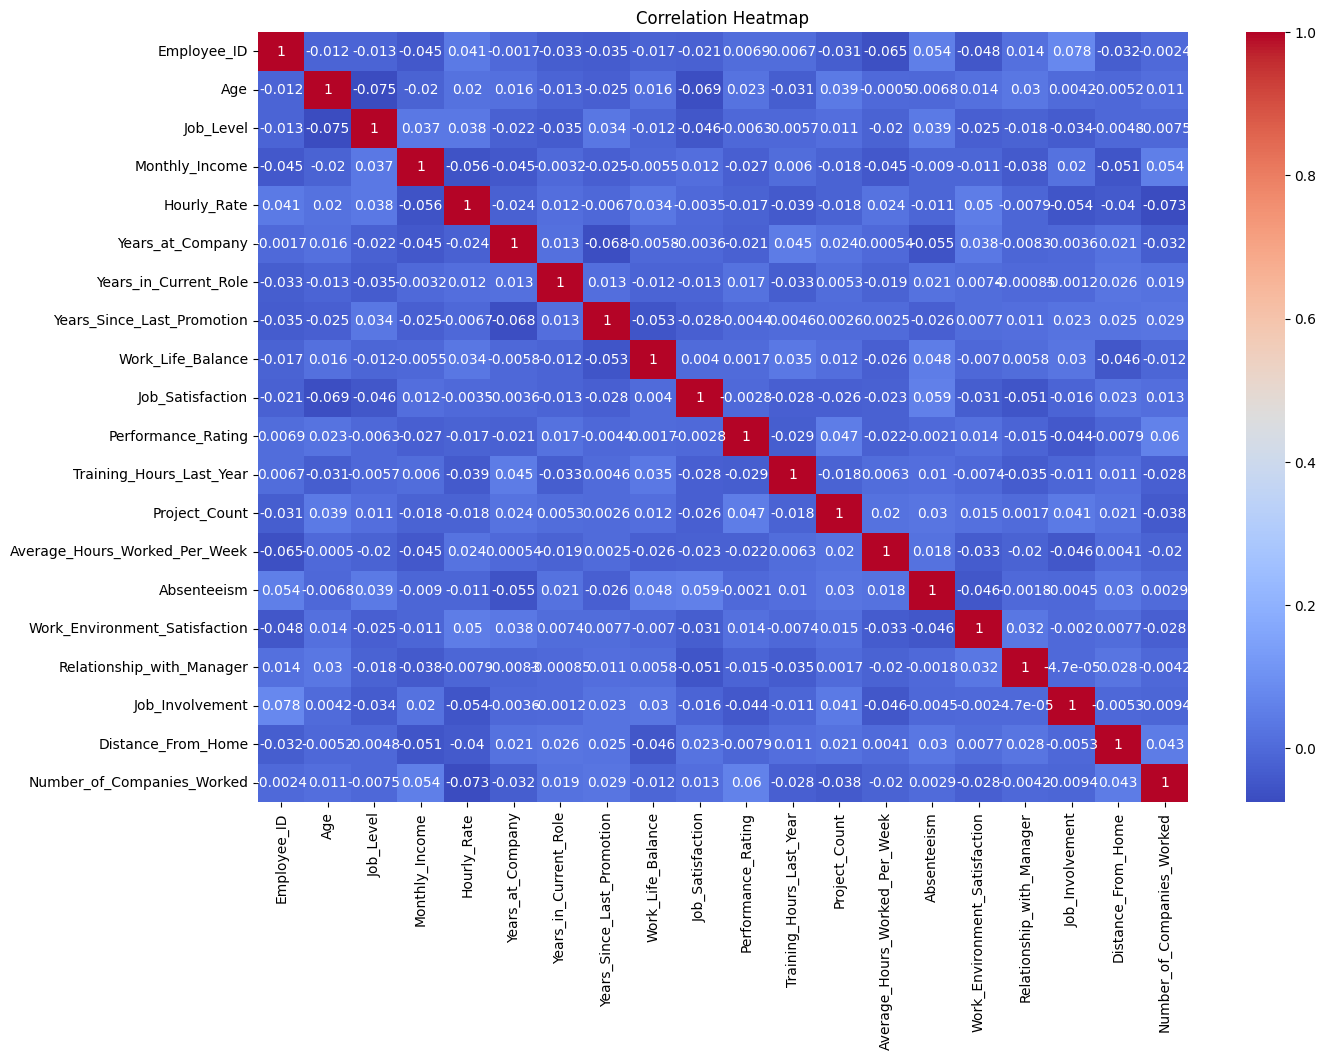

In [48]:
plt.figure(figsize=(15,10))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True , cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

4. Data Preprocessing


Data preprocessing is essential before training machine learning models.

•Encoding categorical variables

In [49]:
label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

Feature and Target Separation

In [50]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

Train-Test Split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Feature Scaling

In [52]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

5. Model Building

Logistic Regression

In [53]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [54]:
y_pred_lr = lr_model.predict(X_test_scaled)

Decision Tree

In [55]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [56]:
y_pred_dt = dt_model.predict(X_test)

Random Forest

In [57]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [58]:
y_pred_rf = rf_model.predict(X_test)

6. Model Evaluation

In [59]:
def evaluate_model(y_test, y_pred, model_name):
    print(f'\n{model_name}')
    print('-'*40)
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('Precision:', precision_score(y_test, y_pred))
    print('Recall:', recall_score(y_test, y_pred))
    print('F1 Score:', f1_score(y_test, y_pred))
    print('\nConfusion Matrix')
    print(confusion_matrix(y_test, y_pred))
    print('\nClassification Report')
    print(classification_report(y_test, y_pred))

Evaluate the models using appropriate metrics

In [60]:
evaluate_model(y_test, y_pred_lr, 'Logistic Regression')


Logistic Regression
----------------------------------------
Accuracy: 0.845
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Confusion Matrix
[[169   0]
 [ 31   0]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      1.00      0.92       169
           1       0.00      0.00      0.00        31

    accuracy                           0.84       200
   macro avg       0.42      0.50      0.46       200
weighted avg       0.71      0.84      0.77       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [61]:
evaluate_model(y_test, y_pred_dt, 'Decision Tree')


Decision Tree
----------------------------------------
Accuracy: 0.685
Precision: 0.22413793103448276
Recall: 0.41935483870967744
F1 Score: 0.29213483146067415

Confusion Matrix
[[124  45]
 [ 18  13]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.73      0.80       169
           1       0.22      0.42      0.29        31

    accuracy                           0.69       200
   macro avg       0.55      0.58      0.54       200
weighted avg       0.77      0.69      0.72       200



In [62]:
evaluate_model(y_test, y_pred_rf, 'Random Forest')


Random Forest
----------------------------------------
Accuracy: 0.845
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Confusion Matrix
[[169   0]
 [ 31   0]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      1.00      0.92       169
           1       0.00      0.00      0.00        31

    accuracy                           0.84       200
   macro avg       0.42      0.50      0.46       200
weighted avg       0.71      0.84      0.77       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

dataset is imbalanced.

Most employees are

Attrition = No

Fewer employees are Attrition = Yes

Because of this imbalance

Logistic Regression predicted mostly "No"

Random Forest also predicted mostly "No"


That is why

Accuracy looks high
But Precision, Recall, and F1 Score become

But failed to detect resigning employees

#Which model performs best


Decision Tree has lower accuracy, it is better because:

It identifies employees likely to leave,Recall is higher (0.42),
HR can take preventive actions,
It does not completely ignore attrition cases

#7. Business Insights and Recommendations



Based on the analysis and visualizations from the notebook, employee attrition is mainly influenced by overtime, salary, job satisfaction, and work-life balance. The graphs show that employees who work overtime are more likely to leave the organization compared to employees who do not work overtime. Similarly, employees with lower monthly income and lower job satisfaction levels show higher attrition rates. These factors indicate that work pressure, stress, and lack of employee satisfaction are major reasons behind resignations.

Employees who frequently work overtime, employees with lower salaries, and employees with poor work-life balance are more likely to leave the company. In addition, employees who have fewer promotion opportunities and lower job satisfaction levels show a greater risk of attrition. These employees may feel stressed, unmotivated, or undervalued in the organization.


From the department-wise attrition analysis in the notebook, some departments show comparatively higher attrition rates than others. This suggests that employees in certain departments may experience higher workload, pressure, or limited growth opportunities. These departments require more attention from HR to improve employee engagement and retention.

To reduce attrition, the HR department should focus on improving employee satisfaction and work culture. The company can reduce excessive overtime, provide better salary benefits, and improve work-life balance policies. Regular employee feedback sessions, recognition programs, wellness activities, and career growth opportunities can also help improve employee retention. In addition, the company can use the machine learning prediction model regularly to identify employees who are at high risk of leaving and take early preventive actions.